# Load Data

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('loan_data_final .csv')
df.head()

,Age,Income,LoanAmount,Credit_Score,Employment_Years,Credit_History,Has_Defaulted,Education_Level,Married,Dependents,Job_Type,Property_Area,Gender,Loan_Status
0,42.0,26263.0,NaN,548.0,7.0,0.0,0,Primary,Married,4.0,Private,Urban,Male,0
1,36.0,32796.0,95450.0,601.0,5.0,1.0,0,Secondary,Single,0.0,Private,Semiurban,Female,1
2,44.0,26115.0,22860.0,554.0,19.0,1.0,0,Primary,Married,2.0,Self_Employed,Semiurban,Male,1
3,53.0,80318.0,NaN,588.0,11.0,1.0,0,University,Married,2.0,Self_Employed,Rural,Female,0
4,35.0,27390.0,83701.0,544.0,8.0,0.0,1,Primary,Single,1.0,Self_Employed,Urban,Male,0


## EDA

In [ ]:
# This code show us the number of rows and columns in our dataset.
df.shape

(1020000, 14)

In [ ]:
# This code show us information about our dataset such as the number of non-null values and the data types of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020000 entries, 0 to 1019999
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Age               1014875 non-null  float64
 1   Income            989255 non-null   float64
 2   LoanAmount        979137 non-null   float64
 3   Credit_Score      969111 non-null   float64
 4   Employment_Years  999580 non-null   float64
 5   Credit_History    938679 non-null   float64
 6   Has_Defaulted     1020000 non-null  int64  
 7   Education_Level   1004805 non-null  object 
 8   Married           989639 non-null   object 
 9   Dependents        994526 non-null   float64
 10  Job_Type          999464 non-null   object 
 11  Property_Area     1009800 non-null  object 
 12  Gender            979099 non-null   object 
 13  Loan_Status       1020000 non-null  int64  
dtypes: float64(7), int64(2), object(5)
memory usage: 108.9+ MB


In [ ]:
# This code show us statistical summary of the numerical columns in our dataset, including count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile, and maximum values.
df.describe()

,Age,Income,LoanAmount,Credit_Score,Employment_Years,Credit_History,Has_Defaulted,Dependents,Loan_Status
count,1.014875e+06,989255.000000,979137.000000,969111.000000,999580.000000,938679.000000,1.020000e+06,994526.000000,1.020000e+06
mean,3.763602e+01,51814.442018,121840.714570,589.691573,8.829245,0.576942,2.573284e-01,1.456505,6.007882e-01
std,9.627577e+00,26358.710355,98437.127624,72.155435,6.941426,0.494045,4.371621e-01,1.397252,4.897366e-01
min,2.000000e+01,5000.000000,10000.000000,300.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,3.100000e+01,32693.000000,51141.000000,547.000000,3.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
50%,3.700000e+01,48221.000000,94975.000000,597.000000,8.000000,1.000000,0.000000e+00,1.000000,1.000000e+00
75%,4.400000e+01,66952.000000,163431.000000,640.000000,13.000000,1.000000,1.000000e+00,2.000000,1.000000e+00
max,6.500000e+01,200000.000000,800000.000000,850.000000,37.000000,1.000000,1.000000e+00,5.000000,1.000000e+00


In [ ]:
# This code show us statistical summary of the categorical columns in our dataset, including count, unique values, top value, and frequency of the top value.
df.describe(include='object')

,Education_Level,Married,Job_Type,Property_Area,Gender
count,1004805,989639,999464,1009800,979099
unique,3,2,4,3,2
top,Secondary,Married,Private,Semiurban,Male
freq,452474,602063,455495,383943,763919


In [ ]:
# This code show us the number of missing values in each column of our dataset.
df.isnull().sum()

Age                  5125
Income              30745
LoanAmount          40863
Credit_Score        50889
Employment_Years    20420
Credit_History      81321
Has_Defaulted           0
Education_Level     15195
Married             30361
Dependents          25474
Job_Type            20536
Property_Area       10200
Gender              40901
Loan_Status             0
dtype: int64

In [ ]:
# This code show us the percentage of missing values in each column of our dataset.
for col in df.columns:
    perc = df[col].isnull().sum() / len(df) * 100
    print(f"{col:<20} {perc:>10.2f}%")

Age                        0.50%
Income                     3.01%
LoanAmount                 4.01%
Credit_Score               4.99%
Employment_Years           2.00%
Credit_History             7.97%
Has_Defaulted              0.00%
Education_Level            1.49%
Married                    2.98%
Dependents                 2.50%
Job_Type                   2.01%
Property_Area              1.00%
Gender                     4.01%
Loan_Status                0.00%


In [ ]:
# This code show us the number of duplicated rows in our dataset.
df.duplicated().sum()

9630

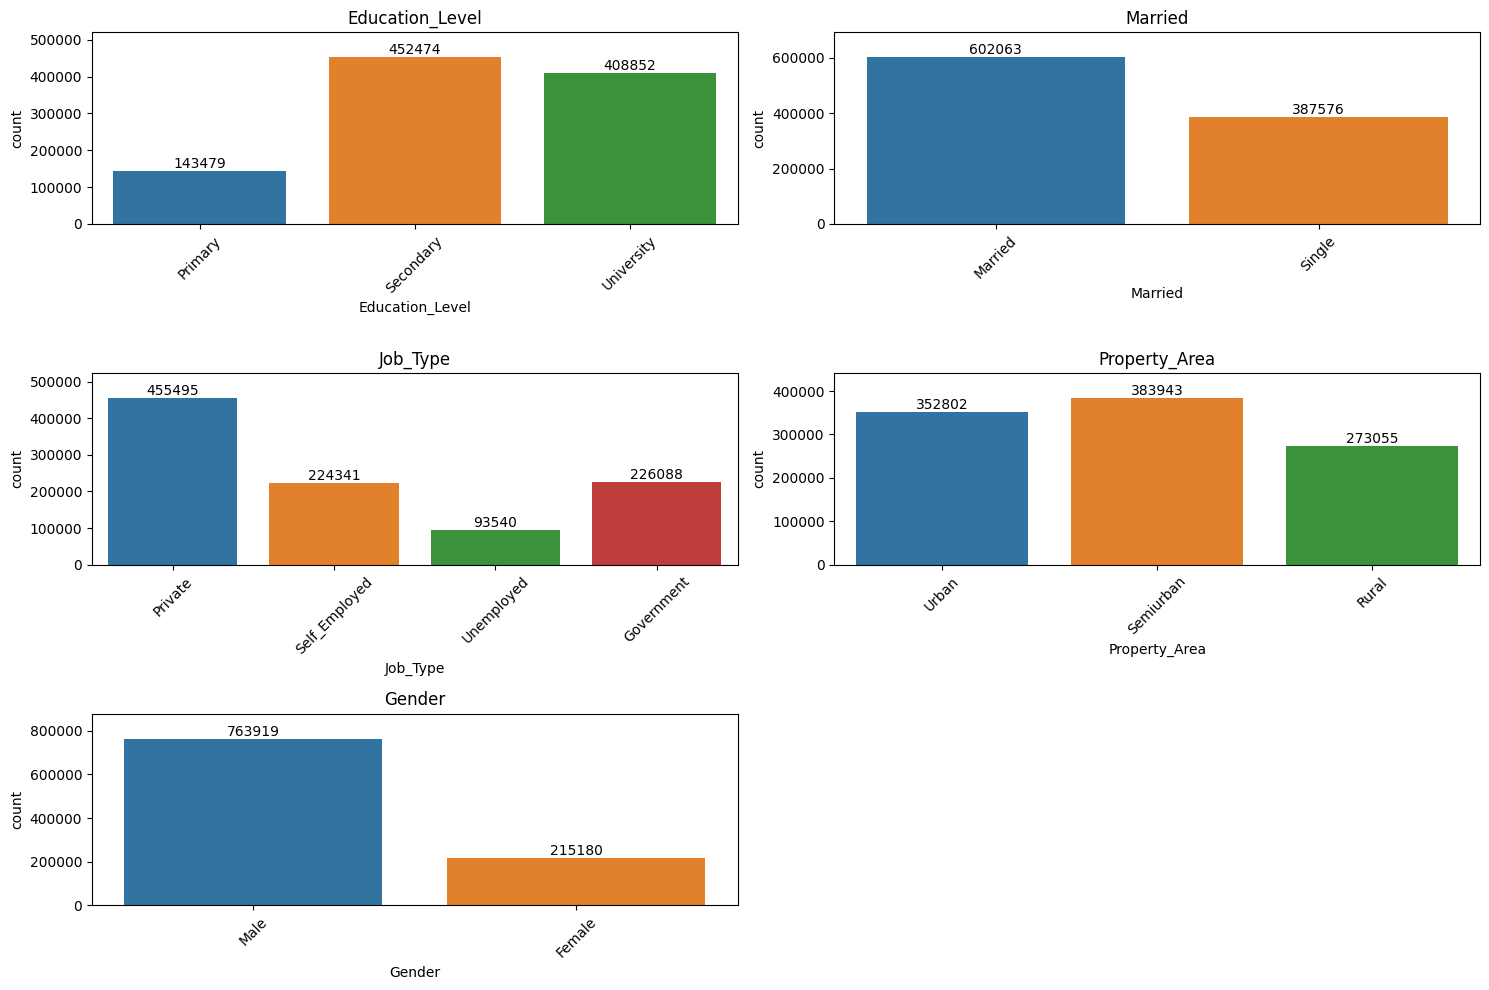

In [ ]:
# This code show us the count of unique values in the specified columns of our dataset.
# After executing this code, We got some insights about distribution of values in categorical columns.
# Insights:
# _ All of categorical columns have inbalanced distribution of values but it differs from one column to another.
# _ As we can see in the output the 'Education_Level' has big inbalance between 'primary' and 'secondary' or 'university' values. 
# _ Also the 'Married' has big inbalance between 'married' and 'single' values.
# _ Also the 'gender' has big inbalance between 'male' and 'female' values.
# _ Also the 'Job_Type' has big inbalance between 'private' and the other values.
# _ finally the 'Property_Area' which has the minimum inbalance between its values but still it is inbalanced especially 'Pural'.

object_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 10))
i = 1
for col in object_cols:
    ax = plt.subplot(3, 2, i)
    sns.countplot(x=col, data=df, ax=ax)
    i+=1
    for container in ax.containers:
        ax.bar_label(container)
    
    ax.margins(y=0.15)

    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\L

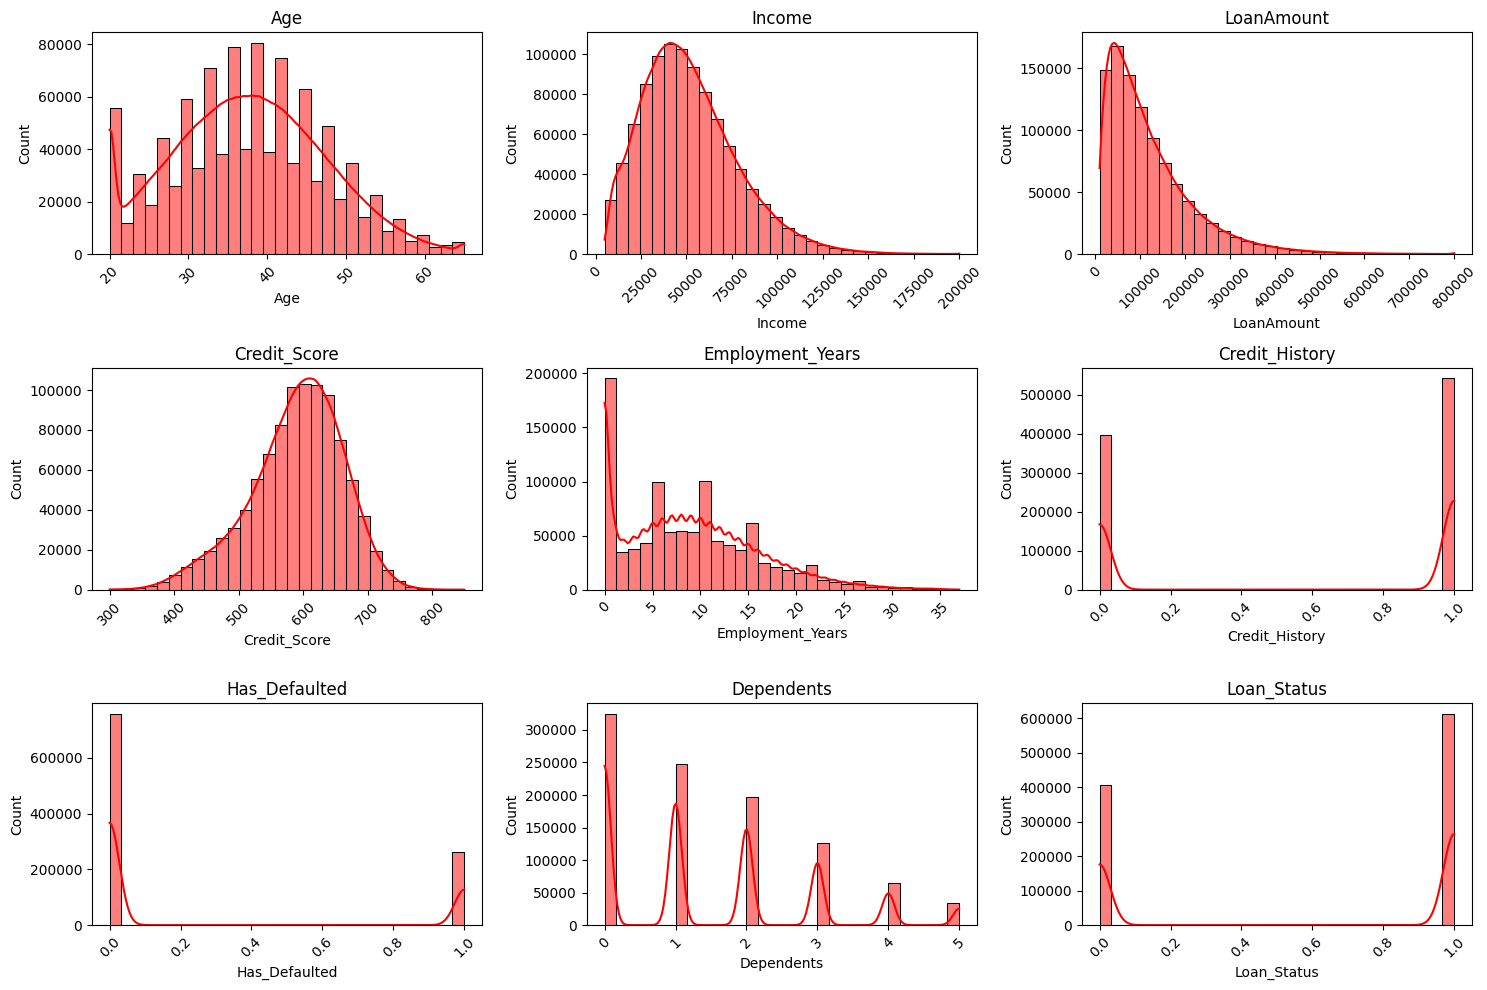

In [64]:
# This code show us the distribution of values in the numerical columns of our dataset using histograms.
numeric_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(15, 10))
i = 1
for col in numeric_cols:
    ax = plt.subplot(3, 3, i)
    sns.histplot(x=col, data=df, ax=ax, kde=True, bins=30, color='red')
    i+=1
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\L

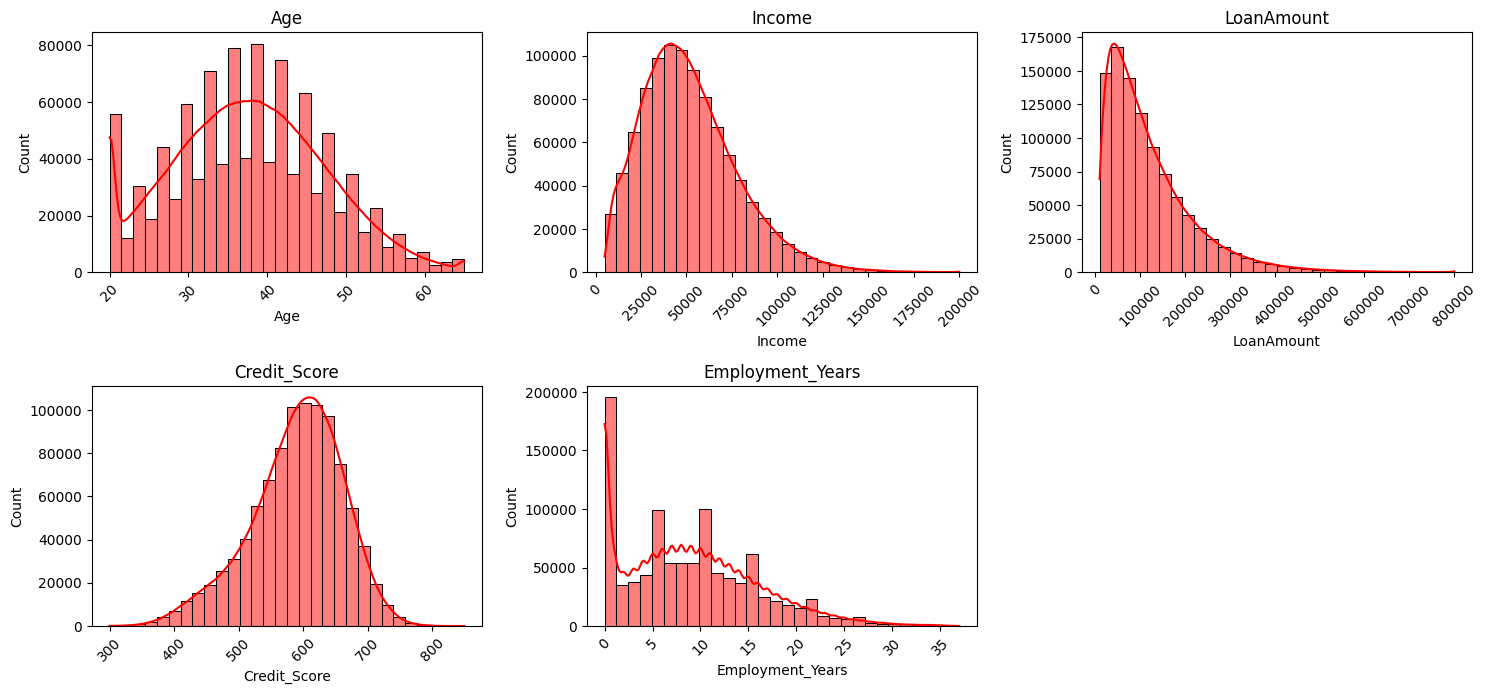

In [66]:
# After executing the above code, We got that there is some columns that have sepcific values.
# To deal with this we will select only the continuous columns to show their distribution using histograms.
# After selecting the continuous columns we got that some insights about the distribution of values in these columns.
# Insights:
# _ The 'Age' column has a normal distribution but with some outliers especially in 20 years old .
# _ The 'Income' columns has a right skewed distribution as we see the most of values are concentrated in the left side of the histogram.
# _ The 'LoanAmount' column has a  right skewed distribution as we see the most of values are concentrated in the left side of the histogram.
# _ The 'Credit_Score' column has a normal distribution but with some outliers especially in 300 and 850 values we can consider it has little skewness to the left.
# _ The 'Employment_Years' column has a right skewed distribution and has inbalanced distribution of values especially in 0 years.
num_continuous_cols =df[['Age','Income','LoanAmount','Credit_Score','Employment_Years']] 

plt.figure(figsize=(15, 10))
i = 1
for col in num_continuous_cols:
    ax = plt.subplot(3, 3, i)
    sns.histplot(x=col, data=df, ax=ax, kde=True, bins=30, color='red')
    i+=1
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# In this code we selected columns that have specific values but they are numerical and we show their value counts.
num_specific_cols = df[['Credit_History', 'Has_Defaulted', 'Dependents', 'Loan_Status']]
for col in num_specific_cols:
    value_count = df[col].value_counts()
    print(f"{value_count} \n ===========================================")

Credit_History
1.0    541563
0.0    397116
Name: count, dtype: int64 
Has_Defaulted
0    757525
1    262475
Name: count, dtype: int64 
Dependents
0.0    324685
1.0    248374
2.0    196228
3.0    126797
4.0     64899
5.0     33543
Name: count, dtype: int64 
Loan_Status
1    612804
0    407196
Name: count, dtype: int64 


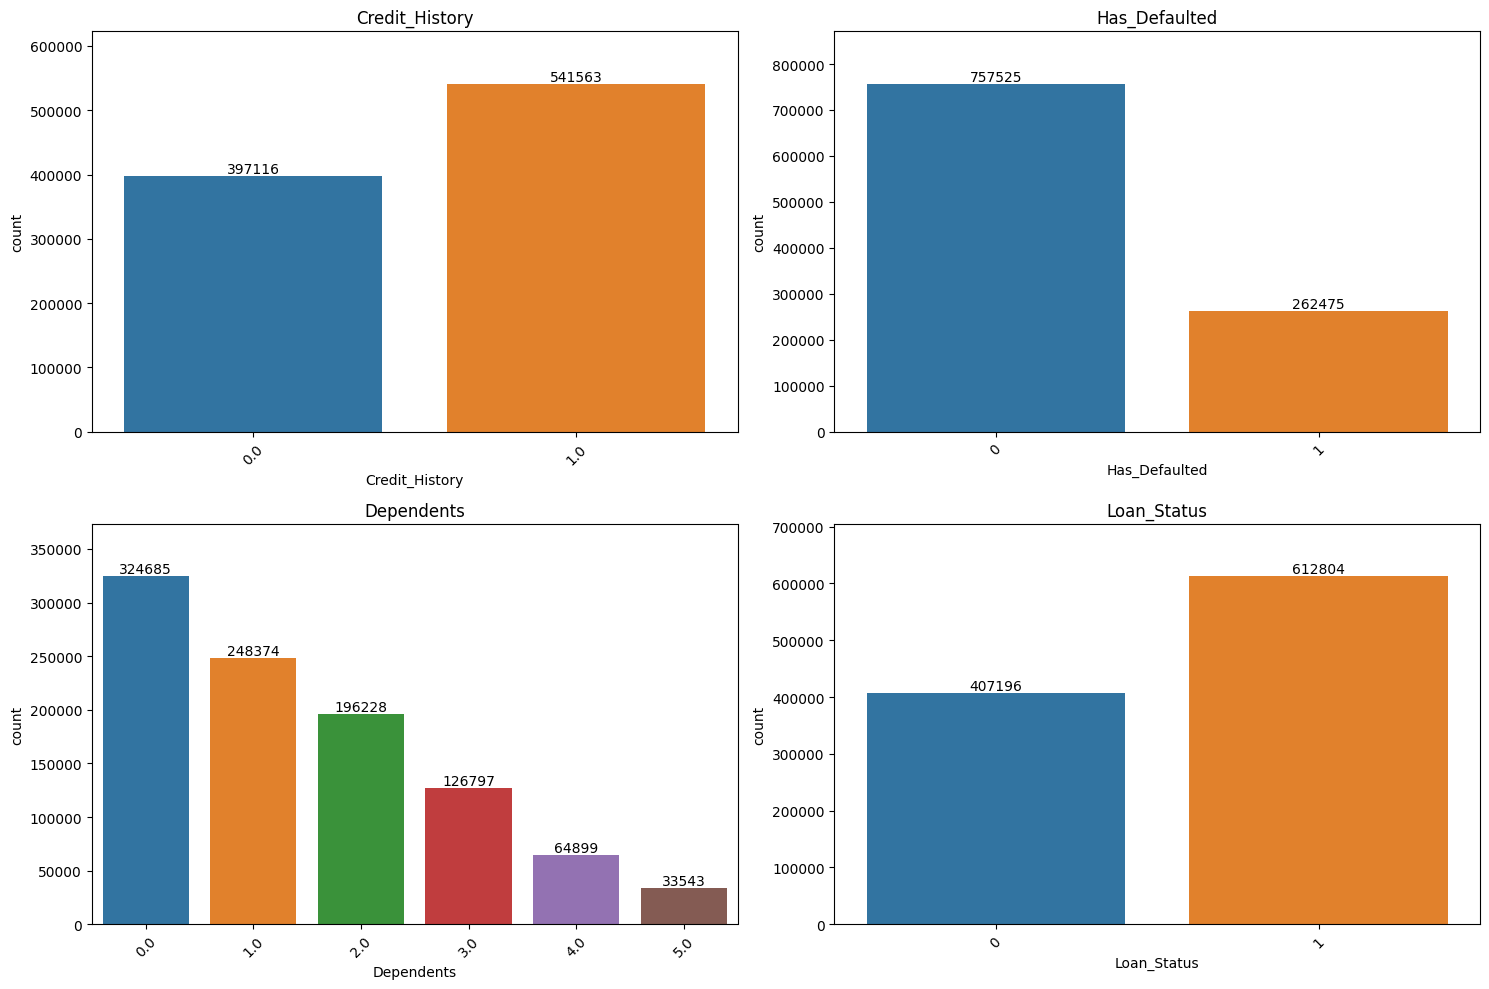

In [ ]:
# After executing this code, We got some insights about distribution of values in these columns.
# Insights:
# _ The 'Credit_History' column has a inbalance between 1.0 and 0.0 values as we see the most of values are concentrated in 1.0 value.
# _ The 'Has_Defaulted' column has a big inbalance between 0 and 1 values as we see the most of values are concentrated in 0 value.
# _ The 'Dependents' column has a inbalance between its values as we see and there is a big inbalance especially between 0 and 5 .
# _ The 'Loan_Status' column has a inbalance between 0 and 1 values as we see the most of values are concentrated in '1' value.

plt.figure(figsize=(15, 10))
i = 1
for col in num_specific_cols:
    ax = plt.subplot(2, 2, i)
    sns.countplot(x=df[col].dropna(), ax=ax)
    i+=1
    for container in ax.containers:
        ax.bar_label(container)
    
    ax.margins(y=0.15)

    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

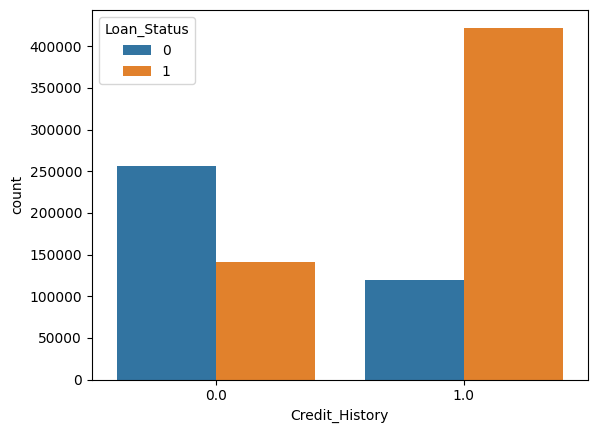

In [81]:
# This code show us the relationship between 'credit history' and 'loan status' columns in our dataset.
# We can see that the applicants who have a good credit history (1.0) are more likely to have their loan approved (Loan_Status = 1) compared to those with a bad credit history (0.0).
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

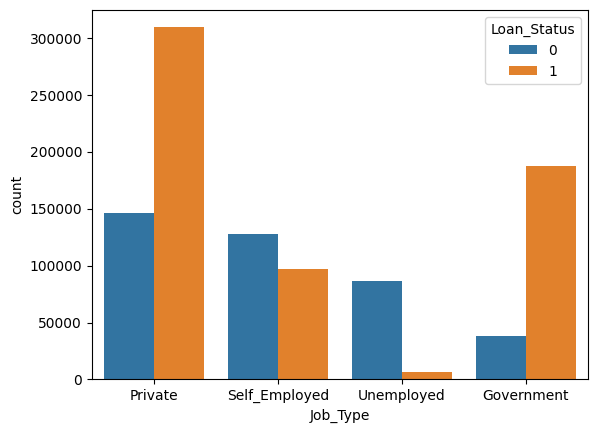

In [80]:
# This code show us the relationship between 'Job_Type' and 'loan status' columns in our dataset.
# We can see that the applicants with 'private' job type are more likely to have their loan approved (Loan_Status = 1) compared to those with other job types.
sns.countplot(x='Job_Type', hue='Loan_Status', data=df)
plt.show()

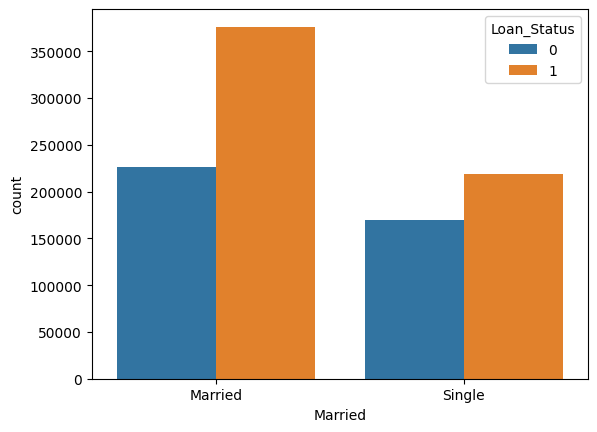

In [79]:
# This code show us the relationship between 'Married' and 'loan status' columns in our dataset.
# We can see that the married applicants are more likely to have their loan approved (Loan_Status = 1) compared to single applicants.
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.show()

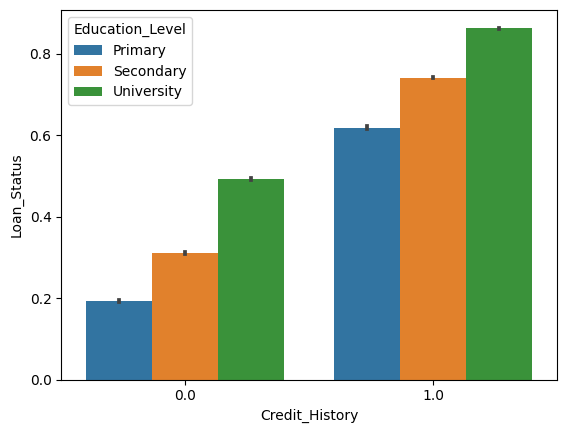

In [82]:
# This code show us the relationship between 'credit history' and 'loan status' columns in our dataset based on the education level of the applicants.
# We can see that the applicants with a good credit history (1.0) are more likely to have their loan approved (Loan_Status = 1) across all education levels.
# but the approval rates are higher for those with higher education levels (secondary and university) compared to those with primary education.
sns.barplot(x='Credit_History', y='Loan_Status', data=df, hue='Education_Level')    
plt.show()

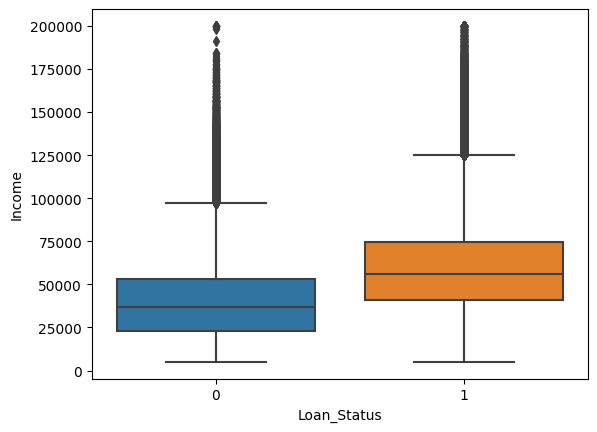

In [83]:
# This code show us the relationship between 'loan status' and 'income' columns in our dataset.
# We can see that the applicants with higher income levels are more likely to have their loan approved (Loan_Status = 1) compared to those with lower income levels.
sns.boxplot(x='Loan_Status', y='Income', data=df)
plt.show()

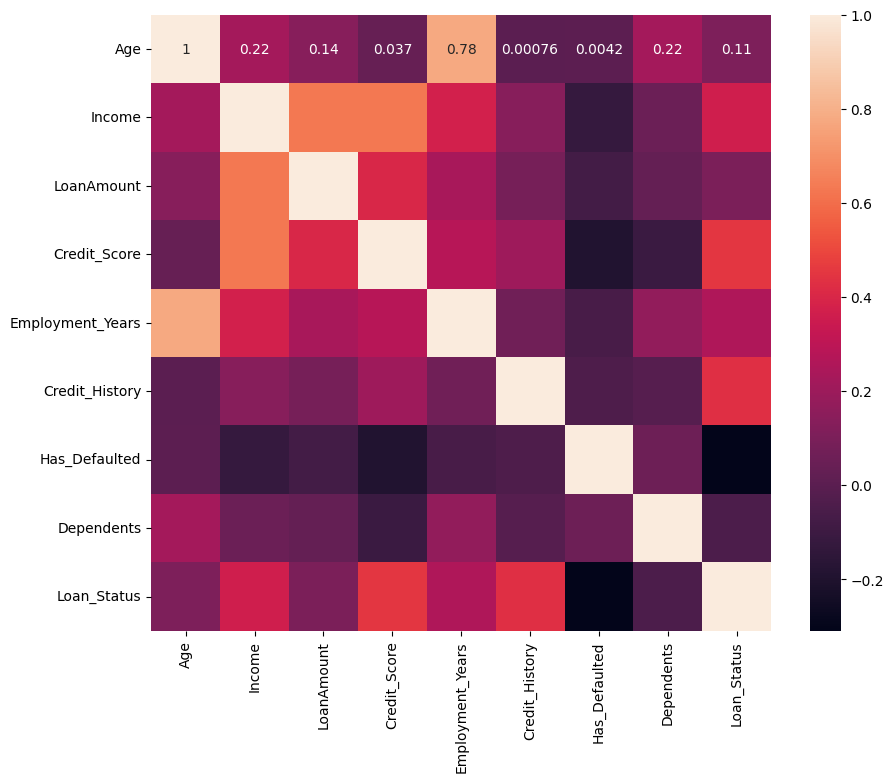

In [ ]:
# This code show us the correlation between the numerical columns in our dataset using a heatmap.
# We can see that there are some strong positive correlations between some columns such as 'Income' and 'LoanAmount' and also between 'Credit_Score' and 'Loan_Status'.
# Also We can see there is strong negative correlation between 'Has_Defaulted' and 'Loan_Status' columns which is expected as the applicants who have defaulted on their loans are less likely to have their loan approved.
# Also We can see there is negative correlation between 'Dependents' and 'Loan_Status' columns which is expected as the applicants who have more dependents are less likely to have their loan approved.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)
plt.show()